# Example notebook: L2 exposures with romanisim, L3 mosaics with romancal

`ray_shooting_and_psf.ipynb` ends with a `SyntheticImage`: the PSF-convolved scene in
counts/sec, sampled at `pixel_scale / oversample`, with the detector pixel integral not yet
applied. This notebook is what `mejiro/pipeline/_05_romanisim.py` does with it.

Two products, from the same inputs:

- **`--level l2`** — tile many systems into one 4088x4088 detector array, run romanisim once
  to apply the full detector-effects chain, cut the systems back out. Output is a single
  exposure in DN/s.
- **`--level l3`** — tile them into the region where every dither of a pattern overlaps, run
  romanisim once per dither, co-add the L2s with romancal's `MosaicPipeline`, and cut the
  systems out of the mosaic. Output is a co-added exposure in MJy/sr at N times the depth.

Along the way, the things that are easy to get wrong and were: where the sub-pixel phase
comes from in each case, what the dither pattern actually commands, why the co-add is
weighted by exposure time rather than inverse variance, and which way round the mosaic axes
run.

**Runtime.** romanisim's ramp simulation is the expensive part: ~8 minutes per exposure on
one core at MA table 10 (233 reads over a 4088x4088 detector). This notebook runs five of
them plus a co-add, so budget around an hour on a first pass. The L2 files are cached under
`CACHE_DIR`, so re-running is fast.

Background reading, all in `docs/`:
[l3_dither_registration.md](../docs/l3_dither_registration.md),
[subpixel_phase.md](../docs/subpixel_phase.md),
[l3_negative_drizzle_weights.md](../docs/l3_negative_drizzle_weights.md),
[l3_cutout_orientation.md](../docs/l3_cutout_orientation.md).

In [36]:
import logging
import os
import shutil
import tempfile
import time
from copy import deepcopy
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

import mejiro

plt.style.use(os.path.join(mejiro.__path__[0], 'mejiro.mplstyle'))
# mejiro.mplstyle turns usetex on and asks for Computer Modern Roman, which only LaTeX can
# supply. With usetex off, matplotlib resolves the serif family itself, so point it at the
# Computer Modern faces bundled with matplotlib. Drop all four if you have a LaTeX install.
plt.rcParams['text.usetex'] = False
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.unicode_minus'] = False  # cmr10 has no Unicode minus glyph

logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(name)s: %(message)s', force=True)

import asdf
import galsim
import roman_datamodels as rdm
import romanisim.bandpass
from astropy import table, units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from romancal.associations import asn_from_list
from romancal.pipeline import MosaicPipeline
from romanisim import image, parameters, wcs as romanisim_wcs

from mejiro.galaxy_galaxy import SampleGG, Sample1, Sample2
from mejiro.instruments.roman import Roman
from mejiro.point_wfi import PointWFI
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import lenstronomy_util, util as mejiro_util
from mejiro.pipeline._05_romanisim import (
    CAL_STEP, DETECTOR_SIZE, DISTORTION_GUARD, MARGIN, PA_APER,
    _cc_to_skycoord, _detector_y_pa_deg, _dither_pixel_offsets, _dither_pointings,
    _extract_cutout, _mosaic_pixel_scale, _overlap_bounds, _place_tile,
    bin_to_native, compute_overlap_skygrid, subpixel_phase,
)
from mejiro.pipeline._05_romanisim import _suppress_third_party_logging

_suppress_third_party_logging()

TEST_DATA = os.path.join(os.path.dirname(mejiro.__path__[0]), 'tests', 'test_data')
CACHE_DIR = os.path.join('/data/bwedig/mejiro/tmp', 'mejiro_l2_l3_notebook')
os.makedirs(CACHE_DIR, exist_ok=True)
print(f'working directory for L2/mosaic artifacts: {CACHE_DIR}')

working directory for L2/mosaic artifacts: /data/bwedig/mejiro/tmp/mejiro_l2_l3_notebook


## 1. Configuration

Everything below comes from the `roman_data_challenge_rung_1` config, so the numbers match a
real production run.

In [37]:
BAND = 'F129'
SCA = 1
FOV_ARCSEC = 10.01          # synthetic_image.fov_arcsec
OVERSAMPLE = 5              # synthetic_image.oversample
SUPERSAMPLING_FACTOR = 3    # synthetic_image.supersampling_factor
MA_TABLE_NUMBER = 10        # exposure.ma_table_number
DATE = '2027-05-01T00:00:00'
SEED = 42
DETECTOR_POSITION = (2048, 2048)

roman = Roman()
pixel_scale = roman.get_pixel_scale(BAND).value
coord = SkyCoord(ra=150.0 * u.deg, dec=2.0 * u.deg)   # exposure.coordinates

read_pattern = parameters.read_pattern[MA_TABLE_NUMBER]
exptime = parameters.read_time * read_pattern[-1][-1]

# the tile size the pipeline derives from the FOV, at Roman's (band-independent) pixel scale
tile_size = int(mejiro_util.set_odd_num_pix(FOV_ARCSEC, pixel_scale))

print(f'MA table {MA_TABLE_NUMBER}: {len(read_pattern)} resultants, '
      f'{read_pattern[-1][-1]} reads, {exptime:.2f} s')
print(f'read pattern: {read_pattern[:3]} ... {read_pattern[-1]}')
print(f'tile size: {tile_size} x {tile_size} px ({tile_size * pixel_scale:.2f} arcsec)')
print(f'L2 grid: {DETECTOR_SIZE // tile_size} x {DETECTOR_SIZE // tile_size} '
      f'= {(DETECTOR_SIZE // tile_size) ** 2} tiles per batch')

MA table 10: 15 resultants, 233 reads, 736.86 s
read pattern: [[1], [2], [3, 4]] ... [233]
tile size: 91 x 91 px (10.01 arcsec)
L2 grid: 44 x 44 = 1936 tiles per batch


### The MA table

Roman WFI reads the detector out non-destructively up a ramp and downlinks *resultants* —
averages of groups of reads. The MA table names which reads go into which resultant, and its
last read sets the exposure time. Table 10 is 15 resultants over 233 reads, 736.86 s.

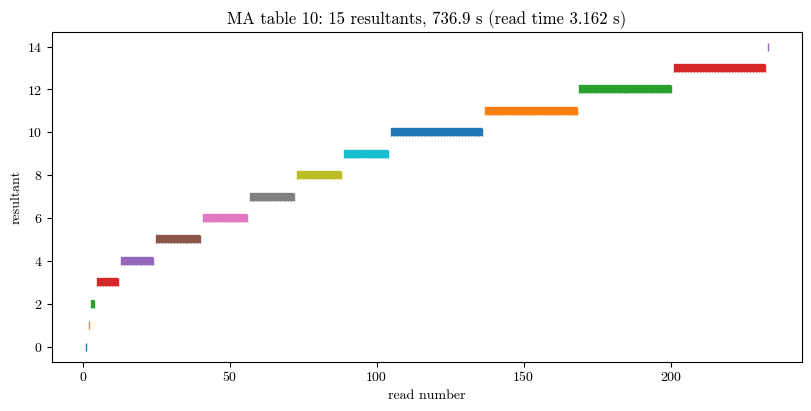

  MA table   3:  5 resultants,    56.92 s
  MA table   4:  9 resultants,   139.15 s
  MA table   5: 12 resultants,   199.24 s
  MA table   6: 15 resultants,   294.11 s
  MA table   7: 15 resultants,   395.31 s
  MA table   8: 15 resultants,   493.35 s
  MA table   9: 15 resultants,   591.38 s
  MA table  10: 15 resultants,   736.86 s
  MA table  11: 15 resultants,   977.20 s
  MA table  12: 15 resultants,   183.42 s
  MA table  13: 15 resultants,   246.67 s
  MA table  14: 15 resultants,   303.60 s
  MA table  15: 15 resultants,   373.17 s
  MA table  16: 15 resultants,   461.72 s
  MA table  17: 15 resultants,   610.36 s
  MA table 109: 10 resultants,   139.15 s
  MA table 110: 16 resultants,   139.15 s


In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, resultant in enumerate(read_pattern):
    ax.plot(resultant, [i] * len(resultant), marker='|', ls='-', lw=6, solid_capstyle='butt')
ax.set_xlabel('read number')
ax.set_ylabel('resultant')
ax.set_title(f'MA table {MA_TABLE_NUMBER}: {len(read_pattern)} resultants, '
             f'{exptime:.1f} s (read time {parameters.read_time:.3f} s)')
plt.show()

for n, rp in sorted(parameters.read_pattern.items()):
    print(f'  MA table {n:>3}: {len(rp):>2} resultants, {parameters.read_time * rp[-1][-1]:>8.2f} s')

## 2. The input systems

mejiro ships three sample lenses. We render each at the production settings, plus one
`SampleGG` with a pyHalo CDM realization, giving four distinct systems to tile.

In [39]:
kernel = np.load(os.path.join(TEST_DATA, f'{BAND}_1_2048_2048_5_101.npy'))
kwargs_psf = lenstronomy_util.get_pixel_psf_kwargs(kernel, 5, degrade=False)
instrument_params = {'detector': SCA, 'detector_position': DETECTOR_POSITION}


def render(strong_lens):
    return SyntheticImage(
        strong_lens, instrument=roman, band=BAND, fov_arcsec=FOV_ARCSEC,
        instrument_params=instrument_params,
        # a fresh dict per construction: SyntheticImage caches supersampled_indexes into it
        kwargs_numerics={'supersampling_factor': SUPERSAMPLING_FACTOR, 'compute_mode': 'regular'},
        kwargs_psf=kwargs_psf, oversample=OVERSAMPLE)


from pyHalo.preset_models import preset_model_from_name

_gg = SampleGG()
CDM = preset_model_from_name('CDM')
realization = CDM(round(_gg.z_lens, 2), round(_gg.z_source, 2), sigma_sub=0.055,
                  cone_opening_angle_arcsec=2.5 * _gg.get_einstein_radius(),
                  LOS_normalization=0., log_mlow=7., log_mhigh=10.,
                  log_m_host=np.log10(_gg.get_main_halo_mass()), r_tidal=0.5)
_gg.add_realization(realization)
_gg.name = 'SampleGG_CDM'

synths = {}
for lens in (SampleGG(), Sample1(), Sample2(), _gg):
    start = time.time()
    synths[lens.name] = render(lens)
    print(f'{lens.name:<16} {synths[lens.name].data.shape} rendered in {time.time() - start:5.2f} s, '
          f'{synths[lens.name].get_maggies():.4e} maggies')

SampleGG         (455, 455) rendered in  0.74 s, 1.3578e-07 maggies
Sample1          (455, 455) rendered in  7.41 s, 5.5514e-08 maggies
Sample2          (455, 455) rendered in  7.57 s, 9.3388e-08 maggies
SampleGG_CDM     (455, 455) rendered in 25.14 s, 1.3498e-07 maggies


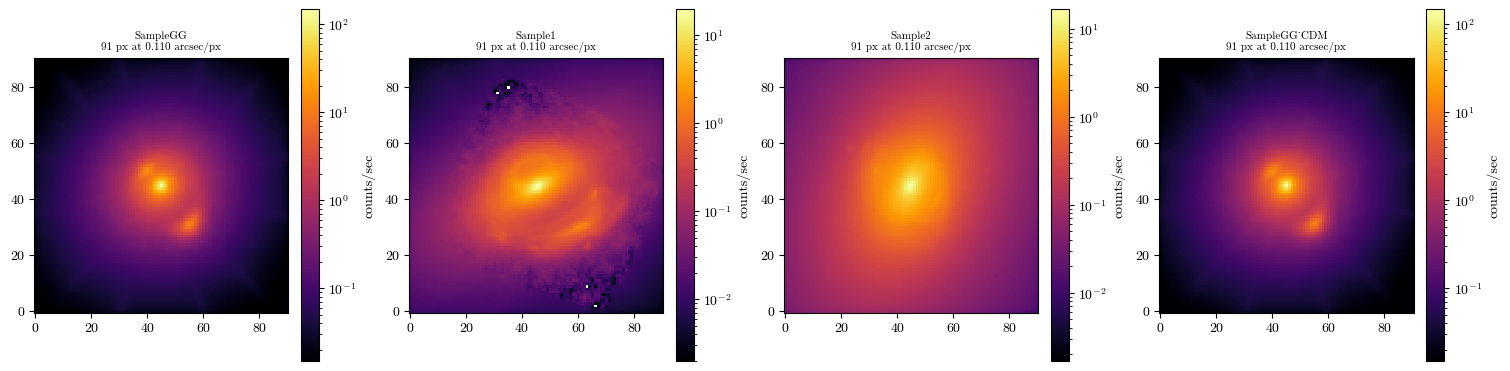

SampleGG              0 negative,    0 NaN of 207,025 rendered px; smooth_pixels changed 0 px
Sample1               0 negative,    0 NaN of 207,025 rendered px; smooth_pixels changed 0 px
Sample2               0 negative,    0 NaN of 207,025 rendered px; smooth_pixels changed 0 px
SampleGG_CDM          0 negative,    0 NaN of 207,025 rendered px; smooth_pixels changed 0 px


In [5]:
fig, axes = plt.subplots(1, len(synths), figsize=(15, 3.6))
for ax, (name, si) in zip(axes, synths.items()):
    binned = bin_to_native(np.asarray(si.data, dtype=np.float64), si.oversample)
    im = ax.imshow(binned, norm=LogNorm(vmin=binned.max() * 1e-4, vmax=binned.max()), cmap='inferno')
    plt.colorbar(im, ax=ax, label='counts/sec')
    ax.set_title(f'{name}\n{binned.shape[0]} px at {si.native_pixel_scale:.3f} arcsec/px', fontsize=8)
plt.show()

# every tile goes through smooth_pixels before it is used; check what it has to fix here
for name, si in synths.items():
    raw = np.asarray(si.data)
    smoothed = np.asarray(mejiro_util.smooth_pixels(raw))
    print(f'{name:<16} {(raw < 0).sum():>6} negative, {np.isnan(raw).sum():>4} NaN '
          f'of {raw.size:,} rendered px; smooth_pixels changed '
          f'{int(np.sum(~np.isclose(raw, smoothed)))} px')

`Sample1` and `Sample2` carry **real COSMOS source images** through an `INTERPOL` light
model rather than an analytic profile, which is why their sources are lumpy where
`SampleGG`'s is a smooth Sersic.

Every tile is passed through `mejiro.utils.util.smooth_pixels` before it is used, which
replaces NaN and negative pixels with the median of their 3x3 neighbourhood. On these four
it is a no-op — the counts above are all zero — but it is applied unconditionally because a
negative pixel would become a negative electron count, which the Poisson draw in section 4.4
cannot accept, and a NaN would poison the whole detector array through the co-add.

## 3. Units: counts/sec to electrons

The step-04 arrays are lenstronomy surface brightness — counts/sec against the SCA's zero
point. romanisim wants **electrons**. The pipeline does not rescale the array by a zero
point; it renormalizes it to the total the lens *should* have and lets romanisim's own
bandpass integration set the absolute scale:

```python
total_electrons = synth.get_maggies() * abflux * exptime
lens_electrons  = (tile / tile.sum()) * total_electrons
```

`romanisim.bandpass.get_abflux(band, sca)` is electrons/sec per maggy for that SCA's
throughput. Normalizing by `tile.sum()` means the shape comes from mejiro and the
normalization from romanisim, so the two cannot disagree about the photometric system.

In [6]:
abflux = romanisim.bandpass.get_abflux(BAND, SCA)
print(f'AB flux, {BAND} on SCA {SCA:02d}: {abflux:.6e} e-/s per maggy')
print(f'exposure time:                {exptime:.4f} s\n')

for name, si in synths.items():
    maggies = si.get_maggies()
    print(f'{name:<16} {maggies:.4e} maggies -> {maggies * abflux * exptime:>12,.0f} e- '
          f'over the ramp')

AB flux, F129 on SCA 01: 3.371221e+10 e-/s per maggy
exposure time:                736.8555 s

SampleGG         1.3578e-07 maggies ->    3,372,802 e- over the ramp
Sample1          5.5515e-08 maggies ->    1,379,052 e- over the ramp
Sample2          9.3388e-08 maggies ->    2,319,847 e- over the ramp
SampleGG_CDM     1.3499e-07 maggies ->    3,353,246 e- over the ramp


## 4. The L2 path

### 4.1 Tiling

One romanisim call costs the same whether the detector holds one system or two thousand, so
the pipeline packs the detector. The grid is `4088 // tile_size` tiles per side, aligned to
(0, 0), leaving the right/top remainder empty.

The assignment is not arbitrary. Each system was rendered with the STPSF kernel for *its*
detector position, so it has to land in the part of the detector that position represents.
`_05_romanisim` buckets systems by `psf.divide_up_detector` and fills each bucket's sub-grid
round-robin. Here all four systems share one detector position, so we simply repeat them
across a corner of the grid — and give each placement its own name, because the sub-pixel
phase is keyed on the name.

In [7]:
grid_side = DETECTOR_SIZE // tile_size
N_ROWS = N_COLS = 6           # a 6x6 corner of the full grid, to keep the figure readable

names = list(synths)
placements = []               # (name, tile_r, tile_c, unique system name)
for r in range(N_ROWS):
    for c in range(N_COLS):
        k = r * N_COLS + c
        placements.append((names[k % len(names)], r, c, f'{names[k % len(names)]}_{k:04d}'))

print(f'full grid would be {grid_side} x {grid_side} = {grid_side ** 2} tiles')
print(f'filling {len(placements)} of them')

full grid would be 44 x 44 = 1936 tiles
filling 36 of them


### 4.2 The sub-pixel phase

The step-04 grid is centred on the deflector and `_place_tile` puts tiles at integer detector
pixels, so binning every system at phase (0, 0) would put every centroid dead centre on a
pixel. That is the most favourable sampling phase there is, identical for every system, and
nothing like what a survey delivers — see
[docs/subpixel_phase.md](../docs/subpixel_phase.md).

L3 has a real phase available from each dither's WCS (section 5). L2 does not, so
`process_batch_l2` draws a deterministic one per system from `seed` + lens name.

SampleGG_0000            phase (-0.1823, -0.3331)
Sample1_0001             phase (+0.2702, -0.1136)
Sample2_0002             phase (+0.1075, +0.2203)
SampleGG_CDM_0003        phase (-0.2466, +0.1296)


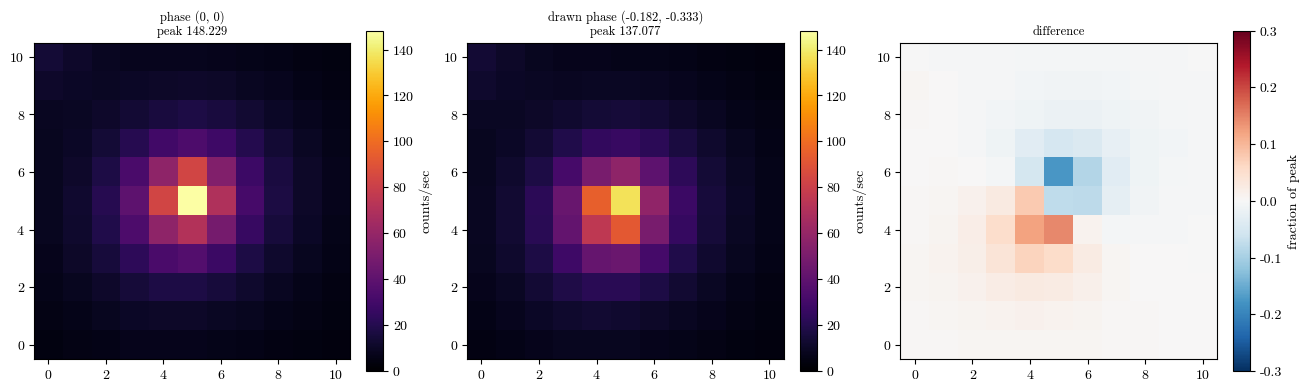

peak pixel moves by -7.5% for this one system
total flux unchanged: 1.000000000000


In [8]:
phases = {n: subpixel_phase(SEED, n) for _, _, _, n in placements}
for n in list(phases)[:4]:
    print(f'{n:<24} phase ({phases[n][0]:+.4f}, {phases[n][1]:+.4f})')

sample_name = placements[0][3]
sample_synth = synths[placements[0][0]]
fine = np.asarray(mejiro_util.smooth_pixels(sample_synth.data), dtype=np.float64)
at_zero = bin_to_native(fine, OVERSAMPLE)
at_drawn = bin_to_native(fine, OVERSAMPLE, *phases[sample_name])

c = at_zero.shape[0] // 2
sl = slice(c - 5, c + 6)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (title, arr) in zip(axes, [('phase (0, 0)', at_zero),
                                   (f'drawn phase {tuple(round(p, 3) for p in phases[sample_name])}',
                                    at_drawn)]):
    im = ax.imshow(arr[sl, sl], cmap='inferno', vmin=0, vmax=at_zero.max())
    plt.colorbar(im, ax=ax, label='counts/sec')
    ax.set_title(f'{title}\npeak {arr.max():.3f}', fontsize=9)
im = axes[2].imshow((at_drawn - at_zero)[sl, sl] / at_zero.max(), cmap='RdBu_r', vmin=-0.3, vmax=0.3)
plt.colorbar(im, ax=axes[2], label='fraction of peak')
axes[2].set_title('difference', fontsize=9)
plt.show()

print(f'peak pixel moves by {at_drawn.max() / at_zero.max() - 1:+.1%} for this one system')
print(f'total flux unchanged: {at_drawn.sum() / at_zero.sum():.12f}')

### 4.3 Building the electron array

For each system: smooth away negative/NaN pixels, bin to detector resolution at its drawn
phase, renormalize to its total electrons, and write it into the detector array.

In [9]:
counts = np.zeros((DETECTOR_SIZE, DETECTOR_SIZE), dtype=np.float64)

for name, tile_r, tile_c, unique in placements:
    synth = synths[name]
    smooth = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)
    assert smooth.shape == (tile_size * OVERSAMPLE, tile_size * OVERSAMPLE)

    frac_x, frac_y = subpixel_phase(SEED, unique)
    native = bin_to_native(smooth, OVERSAMPLE, frac_x, frac_y)

    total_electrons = synth.get_maggies() * abflux * exptime
    electrons = (native / native.sum()) * total_electrons

    r0, c0 = tile_r * tile_size, tile_c * tile_size
    counts[r0:r0 + tile_size, c0:c0 + tile_size] = electrons

print(f'counts: {counts.min():.3e} to {counts.max():.3e} e-, total {counts.sum():,.0f} e-')
print(f'filled {(counts > 0).sum() / counts.size:.2%} of the detector')

counts: 0.000e+00 to 1.094e+05 e-, total 93,824,525 e-
filled 1.78% of the detector


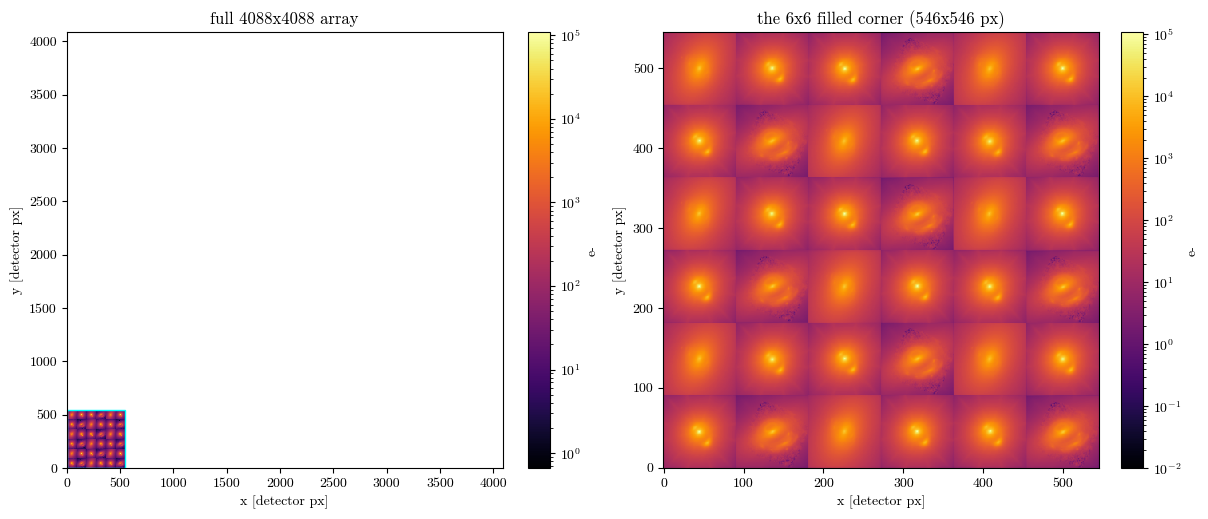

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
zoom = N_ROWS * tile_size
im = axes[0].imshow(np.where(counts > 0, counts, np.nan), norm=LogNorm(), cmap='inferno')
plt.colorbar(im, ax=axes[0], label='e-')
axes[0].add_patch(Rectangle((0, 0), zoom, zoom, fill=False, ec='cyan', lw=1.0))
axes[0].set_title(f'full {DETECTOR_SIZE}x{DETECTOR_SIZE} array')
im = axes[1].imshow(counts[:zoom, :zoom], norm=LogNorm(vmin=1e-2), cmap='inferno')
plt.colorbar(im, ax=axes[1], label='e-')
axes[1].set_title(f'the {N_ROWS}x{N_COLS} filled corner ({zoom}x{zoom} px)')
for ax in axes:
    ax.set_xlabel('x [detector px]')
    ax.set_ylabel('y [detector px]')
plt.show()

### 4.4 Poisson realization

romanisim's `extra_counts` argument takes an **integer** image, so the expected electron
counts are realized as a Poisson draw before being handed over. This is the source shot
noise; every other noise term is romanisim's.

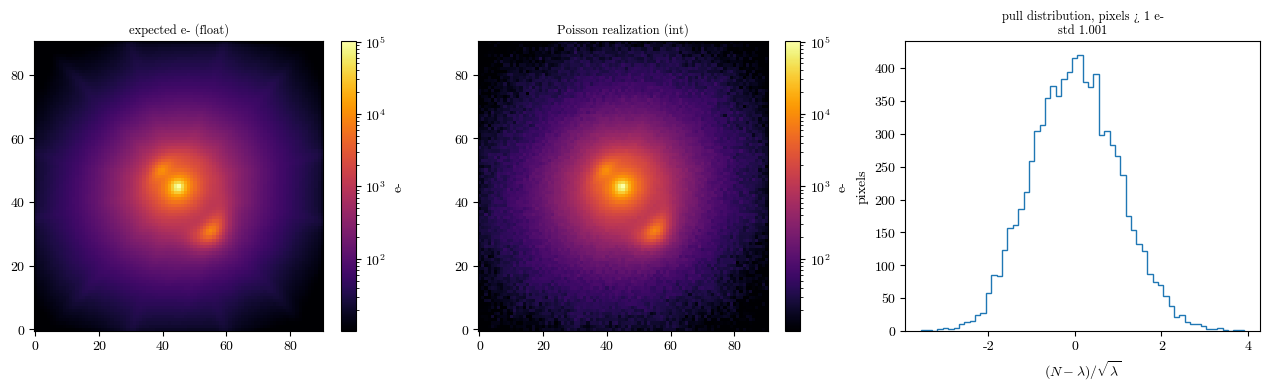

In [11]:
rng_np = np.random.default_rng(SEED)
realized = rng_np.poisson(counts).astype(np.int32)
extra_counts = galsim.ImageI(realized)

tile0 = counts[:tile_size, :tile_size]
tile0_realized = realized[:tile_size, :tile_size].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
norm = LogNorm(vmin=max(tile0.max() * 1e-4, 1e-2), vmax=tile0.max())
for ax, (title, arr) in zip(axes, [('expected e- (float)', tile0),
                                   ('Poisson realization (int)', tile0_realized)]):
    im = ax.imshow(arr, norm=norm, cmap='inferno')
    plt.colorbar(im, ax=ax, label='e-')
    ax.set_title(title, fontsize=9)
bright = tile0 > 1
axes[2].hist(((tile0_realized - tile0) / np.sqrt(tile0))[bright], bins=60, histtype='step')
axes[2].set_xlabel(r'$(N - \lambda) / \sqrt{\lambda}$')
axes[2].set_ylabel('pixels')
axes[2].set_title(f'pull distribution, pixels > 1 e-\n'
                  f'std {np.std(((tile0_realized - tile0) / np.sqrt(tile0))[bright]):.3f}',
                  fontsize=9)
plt.show()

### 4.5 romanisim

`romanisim.image.simulate(..., level=2, extra_counts=...)` takes the electron image and runs
the detector forward model:

1. `simulate_counts` — render any catalog sources and add sky background and dark current,
   giving total electrons for the full ramp. Our `extra_counts` array is added here.
2. `l1.make_l1` — apply inter-pixel capacitance, apportion the electrons up the ramp
   according to the MA table, add cosmic rays and persistence, apply inverse non-linearity,
   and add read noise to every read. The result is an L1 resultant cube.
3. `l1.make_asdf` / `make_l2` — linearity-correct and fit the ramp
   (`fit_ramps_casertano`), then apply the gain. The slope image is the L2 product, in DN/s.

The source catalog is deliberately **empty**: all the flux is already in `extra_counts`, and
we do not want romanisim rendering anything of its own. `usecrds=False` keeps it on its
built-in reference files. Note `crparam=dict()` *enables* cosmic rays with default
parameters — about 99,000 hits per detector over a 736 s ramp — which the ramp fit mostly
rejects by flagging the jump resultant.

In [12]:
def simulate_l2(counts_array, dithered_coord, out_path, seed, pa_aper=None):
    """Run romanisim on an electron array and write the L2 as ASDF. Cached on out_path."""
    if os.path.exists(out_path):
        print(f'  using cached {os.path.basename(out_path)}')
        with asdf.open(out_path) as af:
            return np.array(af['roman']['data'])

    meta = deepcopy(parameters.default_parameters_dictionary)
    meta['instrument']['detector'] = f'WFI{SCA:02d}'
    meta['instrument']['optical_element'] = BAND
    meta['exposure']['ma_table_number'] = MA_TABLE_NUMBER
    meta['exposure']['read_pattern'] = read_pattern
    meta['exposure']['start_time'] = Time(DATE)
    if pa_aper is None:
        romanisim_wcs.fill_in_parameters(meta, dithered_coord, boresight=True)
    else:
        romanisim_wcs.fill_in_parameters(meta, dithered_coord, boresight=True, pa_aper=pa_aper)

    source_catalog = table.Table({
        'ra': np.array([], dtype='f8'), 'dec': np.array([], dtype='f8'),
        'type': np.array([], dtype='U3'), 'n': np.array([], dtype='f4'),
        'half_light_radius': np.array([], dtype='f4'), 'pa': np.array([], dtype='f4'),
        'ba': np.array([], dtype='f4'), BAND: np.array([], dtype='f4'),
    })

    start = time.time()
    im, _ = image.simulate(
        meta, source_catalog, usecrds=False, psftype='galsim', level=2,
        rng=galsim.UniformDeviate(seed), crparam=dict(),
        extra_counts=galsim.ImageI(np.asarray(counts_array, dtype=np.int32)),
    )
    print(f'  romanisim: {time.time() - start:.1f} s')

    # FluxStep prerequisites, which romanisim does not populate
    im['meta']['cal_step'] = deepcopy(CAL_STEP)
    phot = im['meta']['photometry']
    phot['conversion_megajanskys'] = abs(float(phot['conversion_megajanskys']))
    phot['pixel_area'] = abs(float(phot['pixel_area']))

    af = asdf.AsdfFile()
    af.tree = {'roman': im}
    af.write_to(out_path)
    return np.array(im['data'])


l2_path = os.path.join(CACHE_DIR, f'l2_single_wfi{SCA:02d}_{BAND.lower()}_cal.asdf')
print('simulating the single L2 exposure...')
l2_data = simulate_l2(realized, coord, l2_path, SEED)
print(f'L2: {l2_data.shape} {l2_data.dtype}, {np.nanmin(l2_data):.3f} to {np.nanmax(l2_data):.1f} DN/s')

simulating the single L2 exposure...
  using cached l2_single_wfi01_f129_cal.asdf
L2: (4088, 4088) float32, 0.363 to 74.6 DN/s


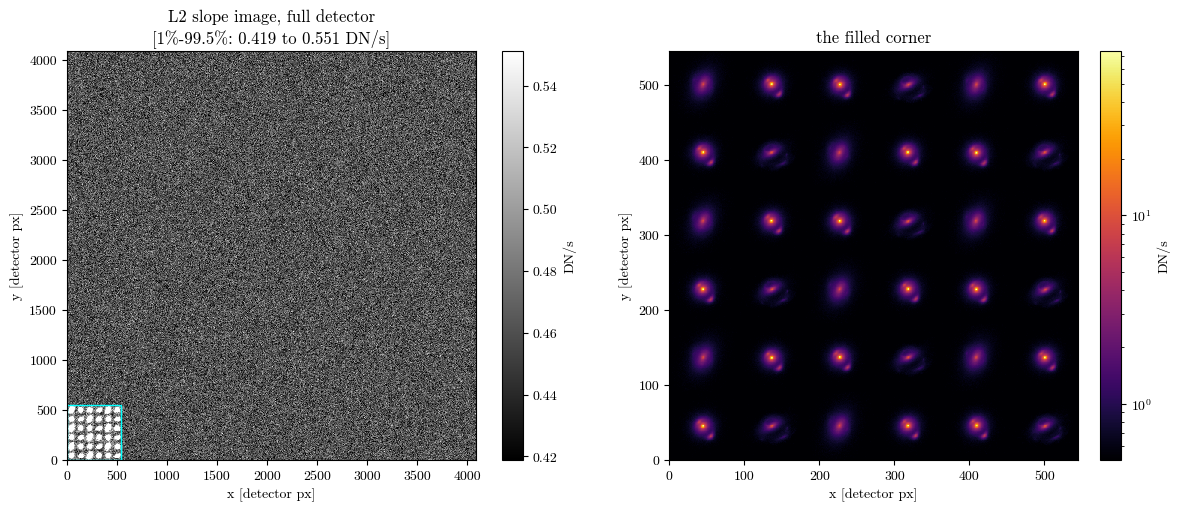

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = np.nanpercentile(l2_data, [1, 99.5])
im = axes[0].imshow(l2_data, vmin=vmin, vmax=vmax, cmap='gray')
plt.colorbar(im, ax=axes[0], label='DN/s')
axes[0].add_patch(Rectangle((0, 0), zoom, zoom, fill=False, ec='cyan', lw=1.0))
axes[0].set_title(f'L2 slope image, full detector\n[1%-99.5%: {vmin:.3f} to {vmax:.3f} DN/s]')

sub = l2_data[:zoom, :zoom]
im = axes[1].imshow(sub, norm=LogNorm(vmin=max(np.nanpercentile(sub, 50), 1e-3),
                                      vmax=np.nanmax(sub)), cmap='inferno')
plt.colorbar(im, ax=axes[1], label='DN/s')
axes[1].set_title('the filled corner')
for ax in axes:
    ax.set_xlabel('x [detector px]')
    ax.set_ylabel('y [detector px]')
plt.show()

### 4.6 What romanisim added

The empty part of the detector is a clean measurement of everything romanisim put in that
mejiro did not: sky background, dark current, read noise, and the ramp-fit statistics.

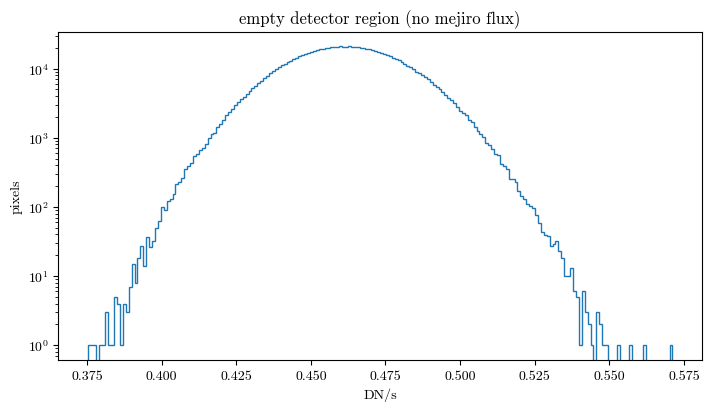

empty region: median 0.4616 DN/s, std 0.0187 DN/s
              = 340 e- over the ramp at gain 1.0

mejiro contributed nothing here; this is romanisim sky + dark + read noise.


In [14]:
empty = l2_data[3000:4000, 3000:4000].astype(np.float64)
empty = empty[np.isfinite(empty)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(empty.ravel(), bins=200, histtype='step')
ax.set_yscale('log')
ax.set_xlabel('DN/s')
ax.set_ylabel('pixels')
ax.set_title('empty detector region (no mejiro flux)')
plt.show()

gain = float(roman.get_gain(BAND))
print(f'empty region: median {np.median(empty):.4f} DN/s, std {np.std(empty):.4f} DN/s')
print(f'              = {np.median(empty) * gain * exptime:,.0f} e- over the ramp at gain {gain}')
print(f'\nmejiro contributed nothing here; this is romanisim sky + dark + read noise.')

### 4.7 Cutouts

Slicing each system back out is the inverse of the tiling, and the L2 product is done.

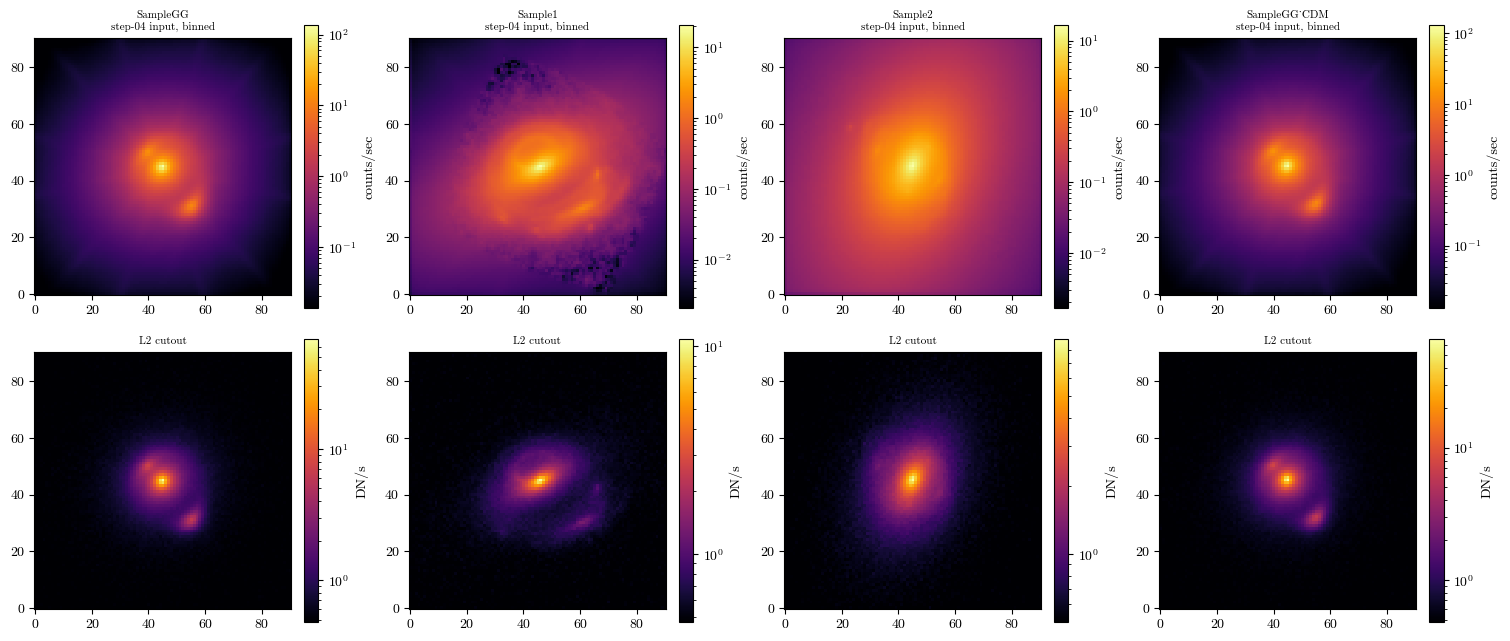

In [15]:
fig, axes = plt.subplots(2, len(names), figsize=(15, 6.4))
for j, name in enumerate(names):
    tile_r, tile_c, unique = next((r, c, u) for n, r, c, u in placements if n == name)
    r0, c0 = tile_r * tile_size, tile_c * tile_size
    cutout = l2_data[r0:r0 + tile_size, c0:c0 + tile_size]

    inp = bin_to_native(np.asarray(mejiro_util.smooth_pixels(synths[name].data), dtype=np.float64),
                        OVERSAMPLE, *subpixel_phase(SEED, unique))
    im = axes[0, j].imshow(inp, norm=LogNorm(vmin=inp.max() * 1e-4, vmax=inp.max()), cmap='inferno')
    plt.colorbar(im, ax=axes[0, j], label='counts/sec')
    axes[0, j].set_title(f'{name}\nstep-04 input, binned', fontsize=8)

    im = axes[1, j].imshow(cutout, norm=LogNorm(vmin=max(np.nanpercentile(cutout, 30), 1e-3),
                                                vmax=np.nanmax(cutout)), cmap='inferno')
    plt.colorbar(im, ax=axes[1, j], label='DN/s')
    axes[1, j].set_title('L2 cutout', fontsize=8)
plt.show()

## 5. The L3 path

An L3 mosaic is a co-add of several dithered L2 exposures, resampled onto a common sky grid.
The pipeline builds one per batch and cuts the systems out of it.

### 5.1 Dither patterns

`PointWFI` reads the STScI dither pattern definitions. There are two families, and they do
very different things.

In [16]:
for name in ('BOXGAP4_1', 'SUB4', 'SUB6'):
    offsets = PointWFI.get_pattern(name)
    print(f'{name} ({len(offsets)} steps)')
    for i, (dx, dy) in enumerate(offsets):
        print(f'  {i}: {dx:>10.3f}, {dy:>10.3f} arcsec  =  '
              f'{dx / pixel_scale:>8.2f}, {dy / pixel_scale:>8.2f} detector px')

BOXGAP4_1 (4 steps)
  0:      0.000,     -0.000 arcsec  =      0.00,    -0.00 detector px
  1:   -205.200,      0.880 arcsec  =  -1865.45,     8.00 detector px
  2:   -204.320,    206.080 arcsec  =  -1857.45,  1873.45 detector px
  3:      0.880,    205.200 arcsec  =      8.00,  1865.45 detector px
SUB4 (4 steps)
  0:      0.000,      0.000 arcsec  =      0.00,     0.00 detector px
  1:     -0.083,     -0.028 arcsec  =     -0.75,    -0.25 detector px
  2:     -0.028,      0.055 arcsec  =     -0.25,     0.50 detector px
  3:      0.055,      0.083 arcsec  =      0.50,     0.75 detector px
SUB6 (6 steps)
  0:      0.000,      0.000 arcsec  =      0.00,     0.00 detector px
  1:      0.019,      0.090 arcsec  =      0.17,     0.82 detector px
  2:      0.090,      0.019 arcsec  =      0.82,     0.17 detector px
  3:      0.036,     -0.064 arcsec  =      0.33,    -0.58 detector px
  4:     -0.055,     -0.081 arcsec  =     -0.50,    -0.74 detector px
  5:     -0.036,      0.009 arcsec  =   

**Gap-filling** patterns like `BOXGAP4_1` step ~205 arcsec — about 1900 detector pixels —
to cover the gaps between SCAs. **Sub-pixel** patterns like `SUB4`/`SUB6` step a fraction of
a pixel, to sample the PSF at controlled sub-pixel phases and beat the undersampling.

The choice changes the economics of the pipeline. With a gap-filling pattern only a fraction
of the detector is covered by every dither, so only that region can hold tiles; with a
sub-pixel pattern essentially the whole detector overlaps and a batch carries far more
systems for the same compute.

It also changes what averages down. A sub-pixel pattern puts each system on nearly the same
pixels every time, so fixed-pattern detector effects (flat error, hot pixels) stay correlated
across the stack instead of averaging out. Per-exposure noise still decorrelates.

We use `SUB4` here: four dithers, so four romanisim calls.

In [17]:
PATTERN = 'SUB4'
pointings = _dither_pointings(coord, PATTERN)
n_dithers = len(pointings)

print(f'{PATTERN}: {n_dithers} pointings, effective depth '
      f'{n_dithers} x {exptime:.1f} = {n_dithers * exptime:.1f} s\n')
print(f'{"dither":>7} {"RA [deg]":>14} {"Dec [deg]":>14}')
for i, p in enumerate(pointings):
    print(f'{i:>7} {p.ra.deg:>14.9f} {p.dec.deg:>14.9f}')

SUB4: 4 pointings, effective depth 4 x 736.9 = 2947.4 s

 dither       RA [deg]      Dec [deg]
      0  150.000000000    2.000000000
      1  150.000018085    2.000016027
      2  149.999990583    2.000014254
      3  149.999972498    1.999998227


### 5.2 The overlap grid

`compute_overlap_skygrid` builds the per-dither WCSes, finds the rectangle of dither-0 pixels
that stays `tile_size/2 + MARGIN` inside **every** dither's footprint, and lays tile centres
across it on a `tile_size + DISTORTION_GUARD` pitch. It returns sky positions, not pixel
positions — the sky is what the dithers have in common.

In [18]:
wcses, source_skies = compute_overlap_skygrid(
    pointings, SCA, BAND, MA_TABLE_NUMBER, read_pattern, DATE, tile_size)

dxs, dys = _dither_pixel_offsets(wcses)
x0_min, x0_max, y0_min, y0_max = _overlap_bounds(dxs, dys, tile_size // 2)

print(f'per-dither integer pixel offsets from dither 0: '
      + ', '.join(f'({dx:+d}, {dy:+d})' for dx, dy in zip(dxs, dys)))
print(f'valid tile-centre box in dither-0 pixels: '
      f'x [{x0_min}, {x0_max}], y [{y0_min}, {y0_max}]')
print(f'capacity: {len(source_skies)} tile slots per batch '
      f'(pitch {tile_size + DISTORTION_GUARD} px)')

per-dither integer pixel offsets from dither 0: (+0, +0), (+1, +0), (+0, +1), (+0, +1)
valid tile-centre box in dither-0 pixels: x [95, 3992], y [95, 3992]
capacity: 1600 tile slots per batch (pitch 98 px)


For comparison, the same computation with a gap-filling pattern — the capacity difference is
the whole argument for sub-pixel patterns in this pipeline:

In [19]:
for name in ('SUB4', 'SUB6', 'BOXGAP4_1', 'BOXGAP6_1'):
    pts = _dither_pointings(coord, name)
    _, skies = compute_overlap_skygrid(pts, SCA, BAND, MA_TABLE_NUMBER, read_pattern,
                                       DATE, tile_size)
    print(f'{name:<12} {len(pts)} dithers -> {len(skies):>5} tile slots/batch')

SUB4         4 dithers ->  1600 tile slots/batch
SUB6         6 dithers ->  1600 tile slots/batch
BOXGAP4_1    4 dithers ->   441 tile slots/batch
BOXGAP6_1    6 dithers ->   441 tile slots/batch


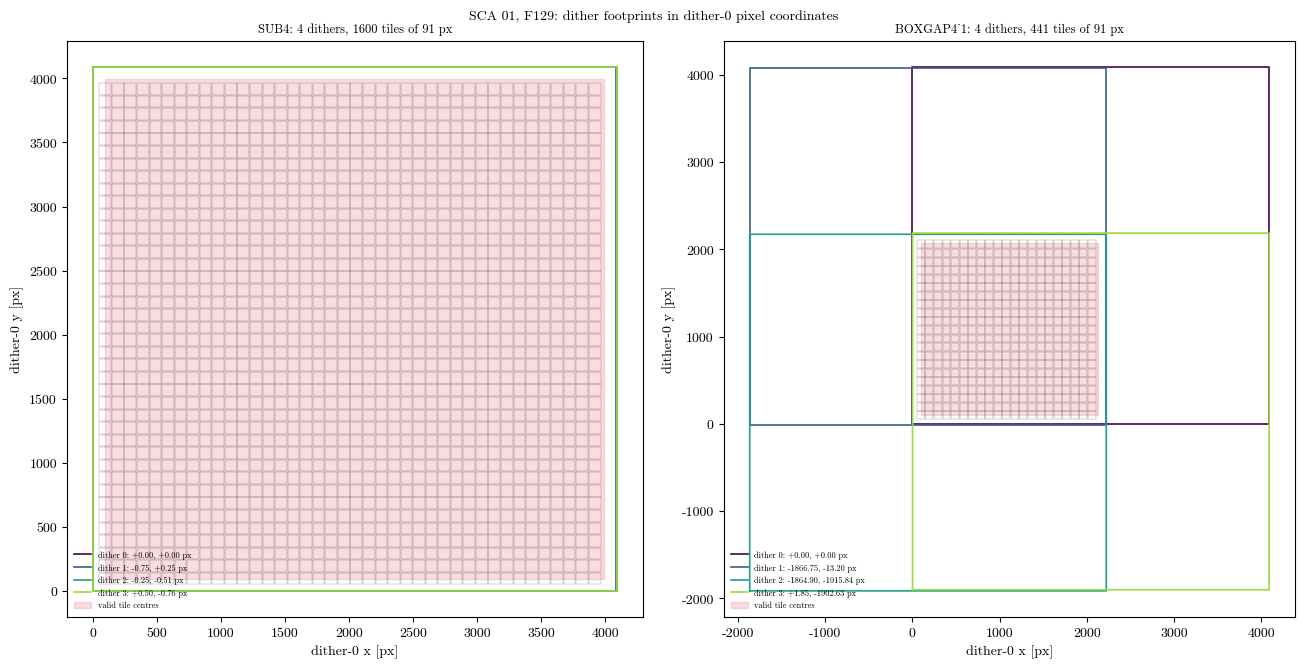

In [20]:
# The pipeline writes this diagnostic per SCA/band as sca##_<band>_dither_overlap.png. Drawn
# here for the sub-pixel pattern we are using and, beside it, a gap-filling one: the two
# panels are the whole reason the capacities above differ by a factor of ~4.
half_tile = tile_size // 2
t = np.linspace(0, DETECTOR_SIZE, 101)
lo, hi = np.zeros_like(t), np.full_like(t, DETECTOR_SIZE)
edge_x = np.concatenate([t, hi, t[::-1], lo])
edge_y = np.concatenate([lo, t, hi, t[::-1]])
centre = DETECTOR_SIZE // 2

fig, axs = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, pattern in zip(axs, (PATTERN, 'BOXGAP4_1')):
    pts = _dither_pointings(coord, pattern)
    w_, skies_ = compute_overlap_skygrid(pts, SCA, BAND, MA_TABLE_NUMBER, read_pattern,
                                         DATE, tile_size)
    dxs_, dys_ = _dither_pixel_offsets(w_)
    bx0, bx1, by0, by1 = _overlap_bounds(dxs_, dys_, half_tile)
    cols = plt.cm.viridis(np.linspace(0, 0.85, len(w_)))

    for d, w in enumerate(w_):
        x, y = w_[0].radecToxy(*w.xyToradec(edge_x, edge_y, units='deg'), units='deg')
        cx, cy = w_[0].radecToxy(*w.xyToradec(centre, centre, units='deg'), units='deg')
        ax.plot(np.append(x, x[0]), np.append(y, y[0]), color=cols[d], lw=1.2, zorder=4,
                label=f'dither {d}: {cx - centre:+.2f}, {cy - centre:+.2f} px')

    if bx1 >= bx0 and by1 >= by0:
        ax.add_patch(Rectangle((bx0, by0), bx1 - bx0, by1 - by0, fc='crimson', ec='crimson',
                               alpha=0.15, lw=1.0, zorder=1, label='valid tile centres'))
        tx, ty = w_[0].radecToxy(np.array([sk.ra / galsim.degrees for sk in skies_]),
                                 np.array([sk.dec / galsim.degrees for sk in skies_]), units='deg')
        ax.add_collection(PatchCollection(
            [Rectangle((x - half_tile, y - half_tile), tile_size, tile_size)
             for x, y in zip(tx, ty)],
            fc='none', ec='k', lw=0.2, alpha=0.6, zorder=2))

    ax.set_aspect('equal')
    ax.set_xlabel('dither-0 x [px]')
    ax.set_ylabel('dither-0 y [px]')
    ax.set_title(f'{pattern}: {len(w_)} dithers, {len(skies_)} tiles of {tile_size} px', fontsize=9)
    ax.legend(loc='lower left', fontsize=6, frameon=False)
fig.suptitle(f'SCA {SCA:02d}, {BAND}: dither footprints in dither-0 pixel coordinates', fontsize=10)
plt.show()

### 5.3 Rounding residuals: what the pattern actually delivers

The tile grid is laid out on **integer dither-0 pixels**, so dither 0 is exact by
construction. Every other dither sees each tile at a position that is not an integer pixel,
and `_place_tile` can only write on whole pixels. Rounding to the nearest one displaces the
rendered system from where the WCS says it is, independently in each dither — by up to
±0.5 px per axis.

The co-add then registers on **sky**, not on the rounded positions, so the N renderings land
at N different mosaic positions and get averaged there. The commanded sub-pixel pattern is
quantized away and replaced with an uncontrolled rounding residual.

In [21]:
def rounding_residuals(wcs_list, skies):
    """(n_slots, n_dithers, 2) array of how far each dither's true position is from the
    integer pixel `_place_tile` would put it on."""
    out = np.zeros((len(skies), len(wcs_list), 2))
    for k, sky in enumerate(skies):
        for d, w in enumerate(wcs_list):
            pos = w.toImage(sky)
            out[k, d] = (pos.x - round(pos.x), pos.y - round(pos.y))
    return out


residuals = rounding_residuals(wcses, source_skies)

print(f'{PATTERN} per-dither residual (dx, dy) in detector px, over {len(source_skies)} tile slots')
print(f'{"dither":>7} {"dx":>18} {"dy":>18}')
for d in range(n_dithers):
    print(f'{d:>7} {residuals[:, d, 0].mean():>+10.4f} +/- {np.ptp(residuals[:, d, 0]):.5f}'
          f' {residuals[:, d, 1].mean():>+10.4f} +/- {np.ptp(residuals[:, d, 1]):.5f}')

# "mutual misregistration": how far apart the extreme dithers place the same system, per axis
spread = residuals.max(axis=1) - residuals.min(axis=1)
print(f'\nmutual misregistration (max - min across dithers, per axis):')
print(f'  x: mean {spread[:, 0].mean():.3f} px, max {spread[:, 0].max():.3f} px')
print(f'  y: mean {spread[:, 1].mean():.3f} px, max {spread[:, 1].max():.3f} px')
print(f'  tile slots where all {n_dithers} dithers round to the same pixel: '
      f'{int(np.all(np.abs(spread) < 1e-9, axis=1).sum())} of {len(source_skies)}')

SUB4 per-dither residual (dx, dy) in detector px, over 1600 tile slots
 dither                 dx                 dy
      0    -0.0000 +/- 0.00000    +0.0000 +/- 0.00000
      1    -0.2503 +/- 0.00005    -0.2530 +/- 0.00004
      2    +0.2518 +/- 0.00002    -0.4894 +/- 0.00003
      3    -0.4979 +/- 0.00007    -0.2364 +/- 0.00007

mutual misregistration (max - min across dithers, per axis):
  x: mean 0.750 px, max 0.750 px
  y: mean 0.489 px, max 0.489 px
  tile slots where all 4 dithers round to the same pixel: 0 of 1600


Dither 0 is exact and no slot escapes. But notice the `+/-` column: for a sub-pixel pattern
the residual is the *same* for every tile slot to within 1e-4 px. That makes sense — the
commanded offsets are a fraction of a pixel and the pointing change is very nearly a pure
translation, so every system on the detector sees the same one.

A gap-filling pattern is different: it slews ~1900 px, so different parts of the detector
see different amounts of WCS distortion and the residual varies from slot to slot. Both are
equally damaging, and for the same reason, but only one of them looks like scatter.

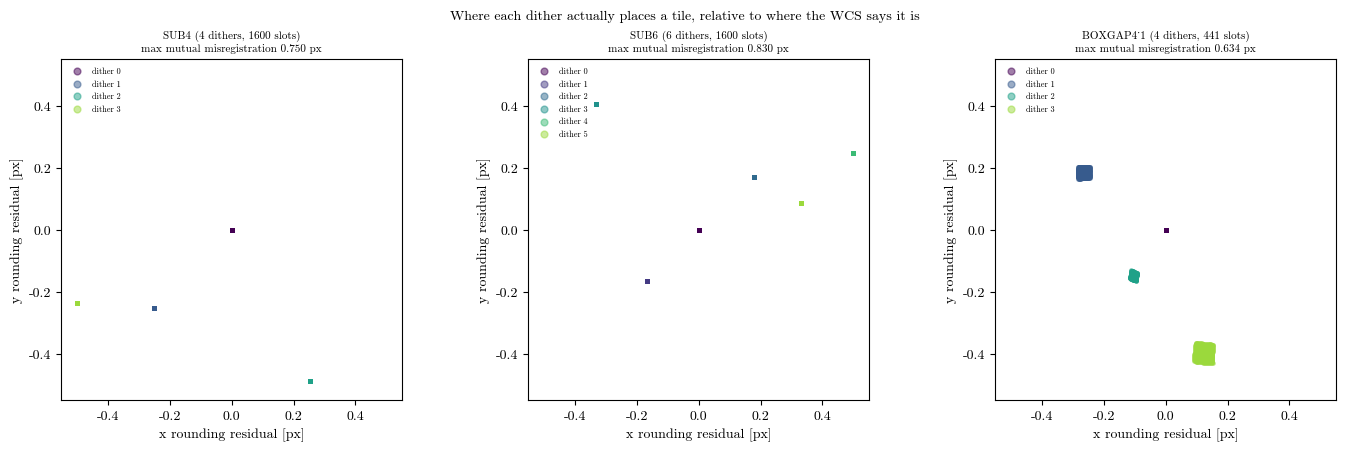

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, pattern in zip(axes, (PATTERN, 'SUB6', 'BOXGAP4_1')):
    pts = _dither_pointings(coord, pattern)
    w_, skies_ = compute_overlap_skygrid(pts, SCA, BAND, MA_TABLE_NUMBER, read_pattern,
                                         DATE, tile_size)
    res_ = rounding_residuals(w_, skies_)
    cols = plt.cm.viridis(np.linspace(0, 0.85, len(pts)))
    for d in range(len(pts)):
        ax.scatter(res_[:, d, 0], res_[:, d, 1], s=6, alpha=0.5, color=cols[d],
                   label=f'dither {d}')
    sp = res_.max(axis=1) - res_.min(axis=1)
    ax.set_xlim(-0.55, 0.55)
    ax.set_ylim(-0.55, 0.55)
    ax.set_aspect('equal')
    ax.set_xlabel('x rounding residual [px]')
    ax.set_ylabel('y rounding residual [px]')
    ax.set_title(f'{pattern} ({len(pts)} dithers, {len(skies_)} slots)\n'
                 f'max mutual misregistration {max(sp[:, 0].max(), sp[:, 1].max()):.3f} px',
                 fontsize=8)
    ax.legend(fontsize=6, markerscale=2, frameon=False, loc='upper left')
fig.suptitle('Where each dither actually places a tile, relative to where the WCS says it is',
             fontsize=10)
plt.show()

### 5.4 The fix: bin at the true sub-pixel phase

The tile still has to be *placed* on a whole pixel — that is a slice assignment. But the
residual can be carried into the **binning phase**, which is where the detector's own pixel
grid enters, and where the oversampled step-04 render makes it exact:

```python
src_pix = wcses[d].toImage(sky)
ix, iy  = int(round(src_pix.x)), int(round(src_pix.y))
native  = bin_to_native(smooth, ov, src_pix.x - ix, src_pix.y - iy)
_place_tile(counts, native, ix, iy, tile_size)
```

The dithers then differ the way the commanded pattern says they should: N genuinely
different detector samplings of the same scene, rather than N copies displaced by rounding
noise.

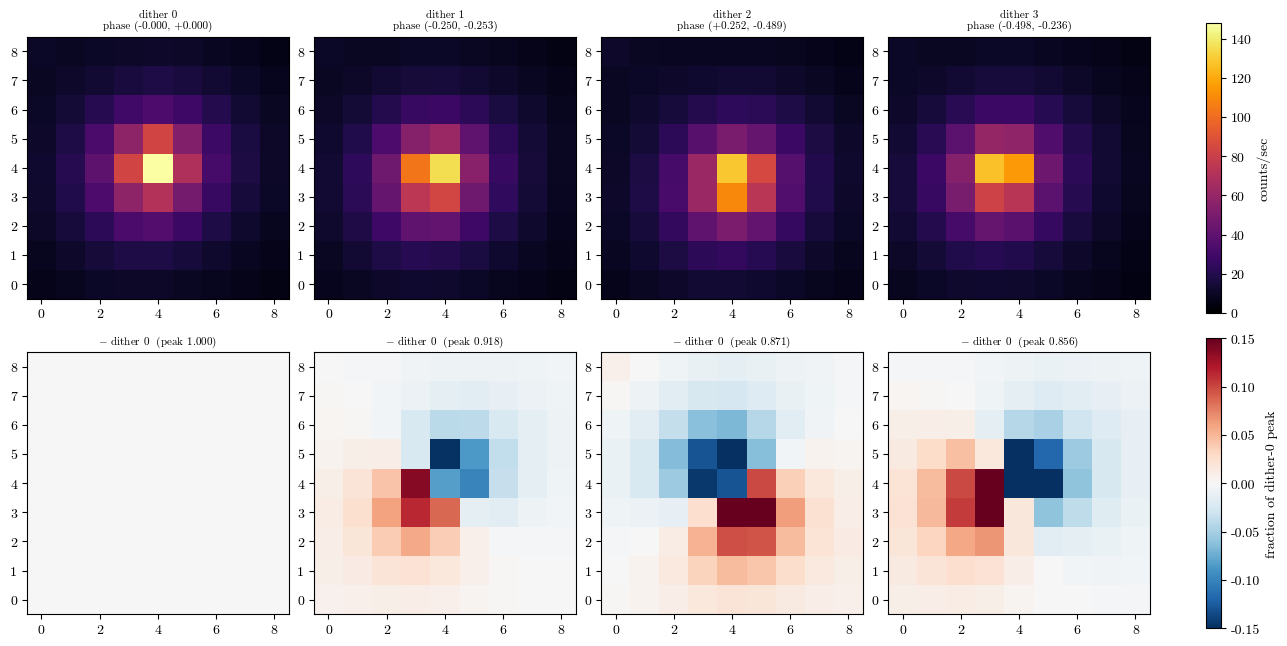

In [23]:
slot = 0
sky0 = source_skies[slot]
fine0 = np.asarray(mejiro_util.smooth_pixels(synths['SampleGG'].data), dtype=np.float64)

fig, axes = plt.subplots(2, n_dithers, figsize=(3.2 * n_dithers, 6.4))
c = tile_size // 2
sl = slice(c - 4, c + 5)
ref = bin_to_native(fine0, OVERSAMPLE)
for d in range(n_dithers):
    p = wcses[d].toImage(sky0)
    ix, iy = int(round(p.x)), int(round(p.y))
    at_phase = bin_to_native(fine0, OVERSAMPLE, p.x - ix, p.y - iy)

    im0 = axes[0, d].imshow(at_phase[sl, sl], cmap='inferno', vmin=0, vmax=ref.max())
    axes[0, d].set_title(f'dither {d}\nphase ({p.x - ix:+.3f}, {p.y - iy:+.3f})', fontsize=8)
    im1 = axes[1, d].imshow((at_phase - ref)[sl, sl] / ref.max(), cmap='RdBu_r',
                            vmin=-0.15, vmax=0.15)
    axes[1, d].set_title(f'$-$ dither 0  (peak {at_phase.max() / ref.max():.3f})', fontsize=8)
plt.colorbar(im0, ax=axes[0, :].tolist(), label='counts/sec')
plt.colorbar(im1, ax=axes[1, :].tolist(), label='fraction of dither-0 peak')
plt.show()

### 5.5 Simulating the dithers

One romanisim call per pointing, each with its own RNG seed so the noise decorrelates.

In [24]:
batch_seed = SEED
l2_files = []
for d, dithered_coord in enumerate(pointings):
    out_path = os.path.join(CACHE_DIR, f'dither{d:04d}_wfi{SCA:02d}_{BAND.lower()}_cal.asdf')
    l2_files.append(out_path)
    if os.path.exists(out_path):
        print(f'dither {d}: cached')
        continue

    dither_counts = np.zeros((DETECTOR_SIZE, DETECTOR_SIZE), dtype=np.float64)
    # note there is no subpixel_phase() call here: L3 has a real phase from the dither WCS,
    # so the drawn one the L2 path uses would only overwrite it
    for k, (name, _, _, _) in enumerate(placements):
        synth = synths[name]
        smooth = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)
        total_electrons = synth.get_maggies() * abflux * exptime

        p = wcses[d].toImage(source_skies[k])
        ix, iy = int(round(p.x)), int(round(p.y))
        native = bin_to_native(smooth, OVERSAMPLE, p.x - ix, p.y - iy)
        _place_tile(dither_counts, (native / native.sum()) * total_electrons,
                    ix, iy, tile_size)

    print(f'dither {d}: {(dither_counts > 0).sum():,} lit pixels, '
          f'{dither_counts.sum():,.0f} e-')
    realized_d = np.random.default_rng(batch_seed + d).poisson(
        np.clip(dither_counts, 0, None)).astype(np.int32)
    simulate_l2(realized_d, dithered_coord, out_path, batch_seed + d, pa_aper=PA_APER)

print(f'\n{len(l2_files)} L2 exposures ready')

dither 0: cached
dither 1: cached


dither 2: 298,116 lit pixels, 93,824,525 e-
  romanisim: 527.4 s
dither 3: 298,116 lit pixels, 93,824,525 e-
  romanisim: 522.8 s

4 L2 exposures ready


### 5.6 Co-adding with romancal

`MosaicPipeline` takes an association of L2 files and drizzles them onto a common grid. Four
of its settings are not defaults, and each one is there because the default was wrong for
this input.

In [25]:
product_name = f'mosaic_sca{SCA:02d}_{BAND}_notebook'
asn_path = os.path.join(CACHE_DIR, f'{product_name}_asn.json')
asn = asn_from_list.asn_from_list([(f, 'science') for f in l2_files],
                                  product_name=product_name, with_exptype=True, target='')
_, serialized = asn.dump(format='json')
with open(asn_path, 'w') as f:
    f.write(serialized)

resample_pixel_scale = _mosaic_pixel_scale(l2_files[0])
resample_rotation = _detector_y_pa_deg(wcses[0])
print(f'resample pixel_scale: {resample_pixel_scale:.6f} arcsec  '
      f'(detector scale is {pixel_scale})')
print(f'resample rotation:    {resample_rotation:.4f} deg')

Maximum specified SIP approximation error: 5   - SIP degree: 1. Maximum residual: 0.0070717* Maximum residual, double sampled grid: 0.0070717* Final SIP degree: 1. Maximum residual: 0.0070717resample pixel_scale: 0.108885 arcsec  (detector scale is 0.11)
resample rotation:    119.8100 deg


**`pixel_scale`.** The resample step normally derives its output scale by differentiating
the WCS at `meta.wcsinfo.ra_ref/dec_ref` — which romanisim sets to the *boresight*, a point
that falls off every SCA. There the derivative degenerates (~1e-9 arcsec/px for SCA 08), the
output shape comes out ~1e11 px square, and drizzle raises "array is too big".
`_mosaic_pixel_scale` evaluates it at the detector centre instead.

**`rotation`.** With `rotation: None` the mosaic comes out north-up, because romanisim's
`wcsinfo` metadata does not describe the galsim WCS it actually simulated with. Passing the
position angle of the detector +y axis keeps the mosaic axes parallel to the detector axes,
so tiles stay axis-aligned and cutouts stay square. See
[docs/l3_cutout_orientation.md](../docs/l3_cutout_orientation.md).

**`weight_type='exptime'`.** romancal defaults to `'ivm'`, i.e. weight = 1/`var_rnoise`. A
romanisim L2 has no `var_rnoise` array — `roman_datamodels`' `WfiImage` schema has no such
field — so romancal reconstructs it as `err**2 - var_poisson`, and *both of those are stored
as float16*. On bright pixels the read-noise term is a tiny fraction of the total variance,
so that subtraction is catastrophic cancellation. Demonstrated below.

**skipping `skymatch`, `outlier_detection`, `source_catalog`.** There is no sky offset
between simulated exposures, no real outlier to reject (the artifacts are deterministic and
near-identical across dithers), and no catalog needed.

In [26]:
# the float16 problem, measured directly on one of the L2s we just made
with rdm.open(l2_files[0]) as m:
    data16 = np.array(m.data, dtype=np.float32)
    err16 = np.array(m.err)
    varp16 = np.array(m.var_poisson)
    has_var_rnoise = hasattr(m, 'var_rnoise')

print(f'L2 err dtype        {err16.dtype}')
print(f'L2 var_poisson      {varp16.dtype}')
print(f'L2 has var_rnoise?  {has_var_rnoise}\n')

reconstructed = err16.astype(np.float32) ** 2 - varp16.astype(np.float32)
print(f'{"data [DN/s]":>14} {"n":>10} {"median var_rnoise":>19} {"fraction < 0":>13}')
for lo, hi in [(0, 1), (1, 5), (5, 20), (20, 50), (50, 100), (100, 1e9)]:
    m_ = (data16 >= lo) & (data16 < hi) & np.isfinite(reconstructed)
    if m_.sum():
        print(f'{f"{lo} - {hi:g}":>14} {m_.sum():>10,} {np.median(reconstructed[m_]):>19.3e} '
              f'{(reconstructed[m_] < 0).mean():>12.1%}')
print('\nA negative variance inverts to a negative drizzle weight; stcal discards only '
      'non-finite\nreciprocals, so it survives, and sum(w*d)/sum(w) then divides by a '
      'denominator that can\ncross zero. See docs/l3_negative_drizzle_weights.md.')

L2 err dtype        float16
L2 var_poisson      float16
L2 has var_rnoise?  False

   data [DN/s]          n   median var_rnoise  fraction < 0
         0 - 1 16,689,887           2.068e-05         0.0%
         1 - 5     20,133           2.100e-05         0.0%
        5 - 20      1,544           3.506e-05         0.0%
       20 - 50        162           3.994e-05         0.0%
      50 - 100         18           1.553e-05         0.0%

A negative variance inverts to a negative drizzle weight; stcal discards only non-finite
reciprocals, so it survives, and sum(w*d)/sum(w) then divides by a denominator that can
cross zero. See docs/l3_negative_drizzle_weights.md.


In [27]:
start = time.time()
MosaicPipeline.call(
    asn_path, save_results=True, output_dir=CACHE_DIR, resample_on_skycell=False,
    configure_log=False,
    steps={
        'skymatch': {'skip': True},
        'outlier_detection': {'skip': True},
        'source_catalog': {'skip': True},
        'resample': {'pixel_scale': resample_pixel_scale,
                     'rotation': resample_rotation,
                     'weight_type': 'exptime'},
    },
)
print(f'MosaicPipeline: {time.time() - start:.1f} s')

coadd_files = glob(os.path.join(CACHE_DIR, '*_coadd.asdf'))
with rdm.open(coadd_files[0]) as mos:
    mos_wcs = mos.meta.wcs
    mos_data = np.array(mos.data, dtype=np.float32)
    mos_weight = np.array(mos.weight, dtype=np.float32)
    mosaic_exptime = float(mos.meta.coadd_info.max_exposure_time)

print(f'mosaic: {mos_data.shape}, {np.nanmin(mos_data):.4f} to {np.nanmax(mos_data):.1f} MJy/sr')
print(f'weight: {np.nanmin(mos_weight):.1f} to {np.nanmax(mos_weight):.1f} '
      f'({(mos_weight < 0).sum()} negative)')
print(f'effective exposure time: {mosaic_exptime:.4f} s '
      f'(expected {n_dithers} x {exptime:.4f} = {n_dithers * exptime:.4f} s)')

MosaicPipeline: 88.3 s
mosaic: (4076, 4129), 0.3085 to 47.4 MJy/sr
weight: 0.0 to 2947.5 (0 negative)
effective exposure time: 2947.4229 s (expected 4 x 736.8555 = 2947.4220 s)


The weight map is a single strictly positive constant — the co-added exposure time — over
the region every dither covers, which is exactly what `weight_type='exptime'` buys. The
pipeline reads `meta.coadd_info.max_exposure_time` off the mosaic and writes it to
`05_romanisim/exposure_time.txt`, because the mosaics live on scratch and are deleted as
soon as the cutouts are extracted; nothing else on disk records the real depth. (It uses
`max_exposure_time` rather than `exposure_time`, which is the mean over covered pixels and
is diluted by the partially covered edges no cutout ever samples.)

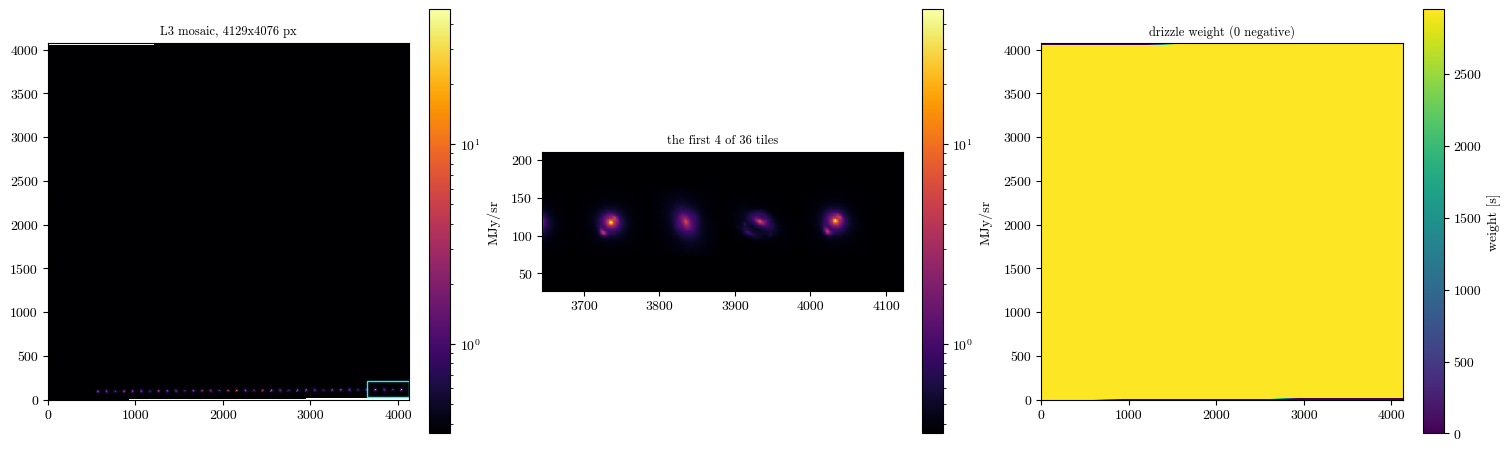

In [28]:
# where our tiles ended up on the mosaic grid, so the zoom panel knows where to look
tile_mos_xy = np.array([[float(v) for v in mos_wcs.world_to_pixel(_cc_to_skycoord(source_skies[k]))]
                        for k in range(len(placements))])
# zoom on the first few tiles: system k goes to overlap-grid slot k, and with 40 slots per
# row our 36 systems all land in the bottom row, which is too long and thin to plot usefully
pad = tile_size
zoom_xy = tile_mos_xy[:len(names)]
x0, x1 = zoom_xy[:, 0].min() - pad, zoom_xy[:, 0].max() + pad
y0, y1 = zoom_xy[:, 1].min() - pad, zoom_xy[:, 1].max() + pad

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
norm = LogNorm(vmin=max(np.nanpercentile(mos_data, 50), 1e-3), vmax=np.nanmax(mos_data))

im = axes[0].imshow(mos_data, norm=norm, cmap='inferno')
plt.colorbar(im, ax=axes[0], label='MJy/sr')
axes[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='cyan', lw=1.0))
axes[0].set_title(f'L3 mosaic, {mos_data.shape[1]}x{mos_data.shape[0]} px', fontsize=9)

im = axes[1].imshow(mos_data, norm=norm, cmap='inferno')
plt.colorbar(im, ax=axes[1], label='MJy/sr')
axes[1].set_xlim(x0, x1)
axes[1].set_ylim(y0, y1)
axes[1].set_title(f'the first {len(names)} of {len(placements)} tiles', fontsize=9)

im = axes[2].imshow(mos_weight, cmap='viridis')
plt.colorbar(im, ax=axes[2], label='weight [s]')
axes[2].set_title(f'drizzle weight ({(mos_weight < 0).sum()} negative)', fontsize=9)
plt.show()

### 5.7 Cutouts, and a parity flip

Each system is cut out of the mosaic at its **true sky position**, via the mosaic WCS — not
at a remembered pixel position. That is what makes the cutout correctly centred even though
each dither's rendering was displaced by its rounding residual.

One more thing has to happen: the mosaic x axis is antiparallel to the detector x axis. The
resample `rotation` aligns the axes but cannot fix a parity mismatch, so the cutout is
flipped left-right to match the input orientation. This is
[docs/l3_cutout_orientation.md](../docs/l3_cutout_orientation.md); it is invisible on a
symmetric system and obvious on an asymmetric one, which is exactly how it survived.

In [29]:
l3_cutouts = {}
for k, (name, _, _, _) in enumerate(placements[:len(names)]):
    mx, my = mos_wcs.world_to_pixel(_cc_to_skycoord(source_skies[k]))
    cutout = _extract_cutout(mos_data, int(round(float(mx))), int(round(float(my))), tile_size)
    l3_cutouts[name] = np.fliplr(cutout)
    print(f'{name:<16} mosaic pixel ({float(mx):8.2f}, {float(my):8.2f})  '
          f'-> cutout {cutout.shape}, {np.nanmin(cutout):.3f} to {np.nanmax(cutout):.1f} MJy/sr')

SampleGG         mosaic pixel ( 4032.05,   119.59)  -> cutout (91, 91), 0.344 to 40.5 MJy/sr
Sample1          mosaic pixel ( 3933.12,   119.00)  -> cutout (91, 91), 0.341 to 7.1 MJy/sr
Sample2          mosaic pixel ( 3834.18,   118.41)  -> cutout (91, 91), 0.346 to 6.1 MJy/sr
SampleGG_CDM     mosaic pixel ( 3735.25,   117.82)  -> cutout (91, 91), 0.346 to 42.1 MJy/sr


In [30]:
def correlation(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[m], b[m])[0, 1])


raw_cutouts, inputs = {}, {}
for k, (name, _, _, _) in enumerate(placements[:len(names)]):
    mx, my = mos_wcs.world_to_pixel(_cc_to_skycoord(source_skies[k]))
    raw_cutouts[name] = _extract_cutout(mos_data, int(round(float(mx))),
                                        int(round(float(my))), tile_size)
    inputs[name] = bin_to_native(
        np.asarray(mejiro_util.smooth_pixels(synths[name].data), dtype=np.float64), OVERSAMPLE)

print(f'{"system":<16} {"as extracted":>14} {"after fliplr":>14}   correlation with the step-04 input')
for name in names:
    print(f'{name:<16} {correlation(raw_cutouts[name], inputs[name]):>14.5f} '
          f'{correlation(np.fliplr(raw_cutouts[name]), inputs[name]):>14.5f}')

system             as extracted   after fliplr   correlation with the step-04 input
SampleGG                0.91379        0.94780
Sample1                 0.90023        0.99570
Sample2                 0.95415        0.99783
SampleGG_CDM            0.92476        0.96800


Read the *difference* between the two columns, not the absolute values: the co-add carries
noise, sits on a slightly different pixel grid, and is being compared against a noiseless
render, so no orientation can reach 1.0. Every system prefers the flipped one, and by a
margin far larger than any of that.

The margin is largest for the systems with the most off-axis structure to disagree about.
A parity flip is an exact symmetry of a left-right symmetric image, so on a round system it
is nearly invisible — which is how the orientation defect in
[docs/l3_cutout_orientation.md](../docs/l3_cutout_orientation.md) survived until someone
made precisely this comparison.

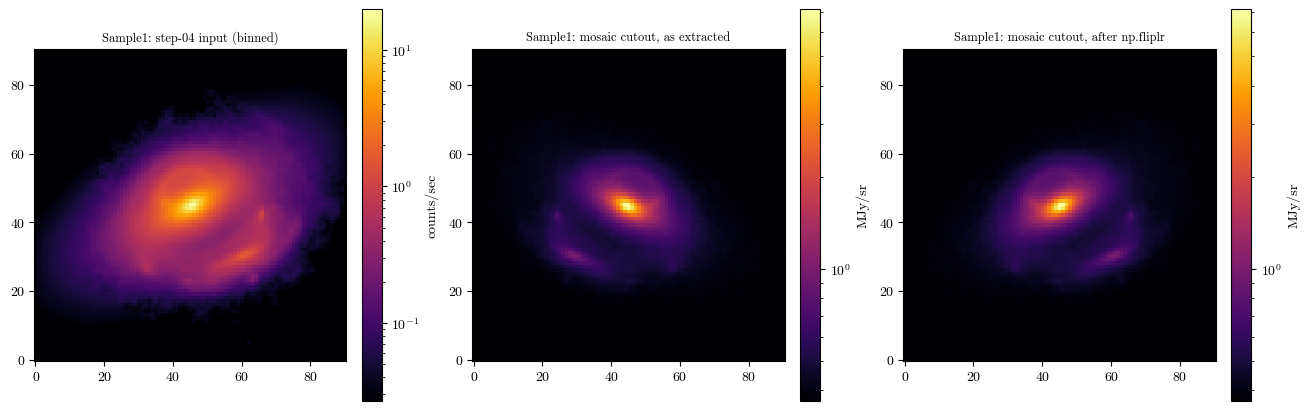

In [31]:
name = 'Sample1'   # the real COSMOS source, i.e. the one asymmetric enough to show it
raw = raw_cutouts[name]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, arr, label) in zip(axes, [
        ('step-04 input (binned)', inputs[name], 'counts/sec'),
        ('mosaic cutout, as extracted', raw, 'MJy/sr'),
        ('mosaic cutout, after np.fliplr', np.fliplr(raw), 'MJy/sr')]):
    im = ax.imshow(arr, norm=LogNorm(vmin=max(np.nanpercentile(arr, 40), 1e-4),
                                     vmax=np.nanmax(arr)), cmap='inferno')
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(f'{name}: {title}', fontsize=9)
plt.show()

## 6. L2 against L3

Same systems, same input, same MA table. The L3 is four exposures deep and in surface
brightness units; the L2 is one exposure in DN/s.

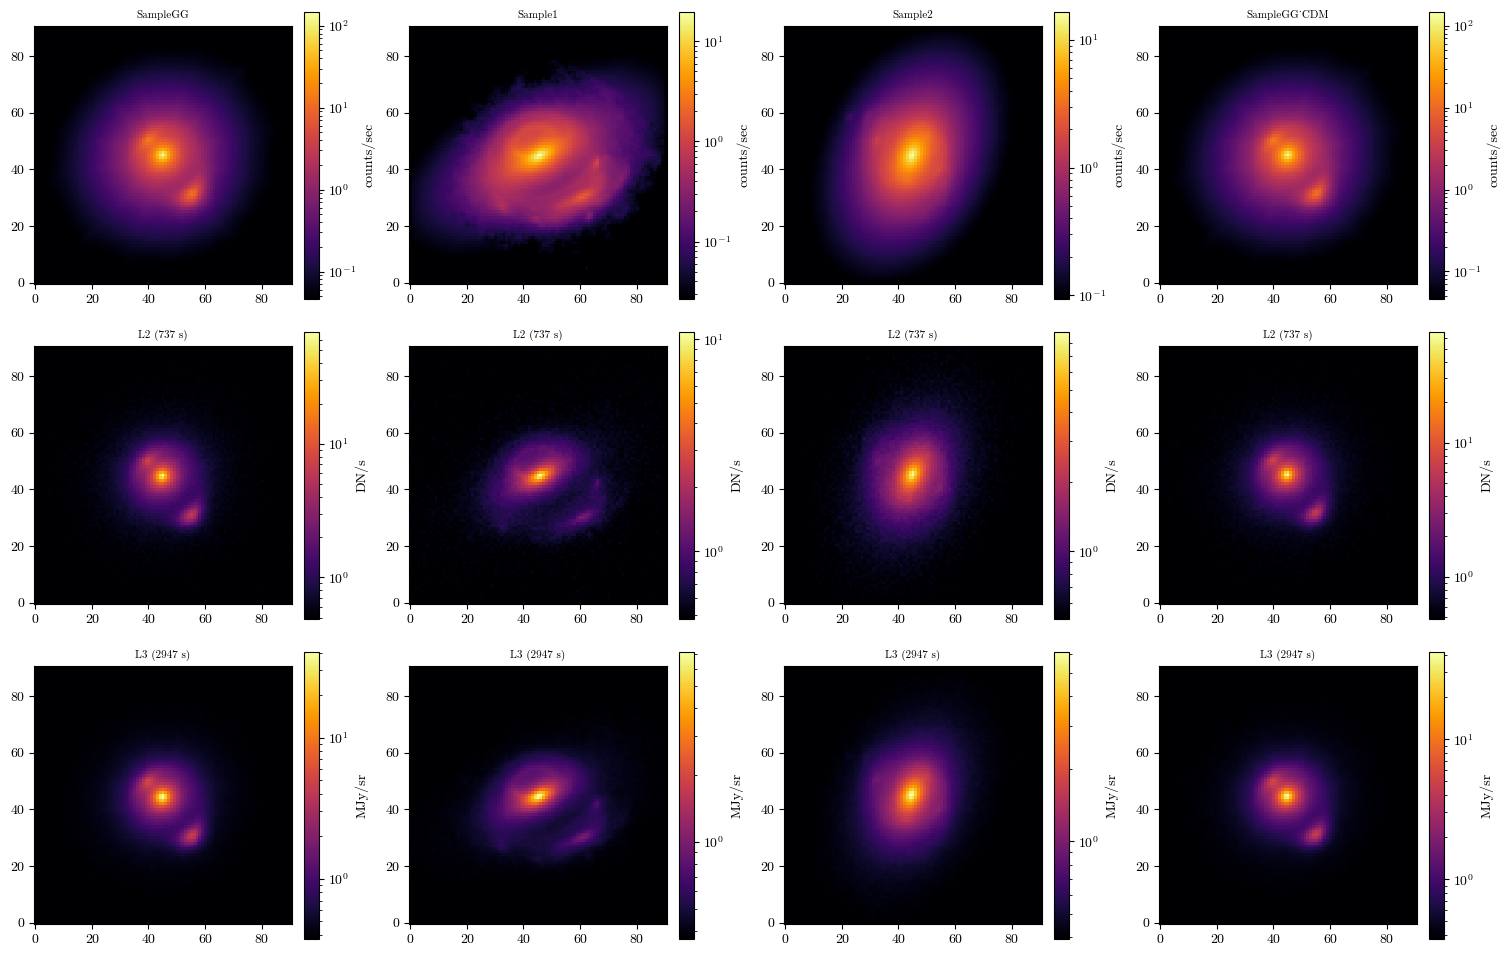

In [32]:
fig, axes = plt.subplots(3, len(names), figsize=(15, 9.6))
for j, name in enumerate(names):
    tile_r, tile_c = next((r, c) for n, r, c, _ in placements if n == name)
    r0, c0 = tile_r * tile_size, tile_c * tile_size
    l2_cutout = l2_data[r0:r0 + tile_size, c0:c0 + tile_size]
    l3_cutout = l3_cutouts[name]
    inp = bin_to_native(np.asarray(mejiro_util.smooth_pixels(synths[name].data), dtype=np.float64),
                        OVERSAMPLE)

    for i, (arr, label, title) in enumerate([
            (inp, 'counts/sec', 'step-04 input'),
            (l2_cutout, 'DN/s', f'L2 ({exptime:.0f} s)'),
            (l3_cutout, 'MJy/sr', f'L3 ({mosaic_exptime:.0f} s)')]):
        im = axes[i, j].imshow(arr, norm=LogNorm(vmin=max(np.nanpercentile(arr, 40), 1e-4),
                                                 vmax=np.nanmax(arr)), cmap='inferno')
        plt.colorbar(im, ax=axes[i, j], label=label)
        axes[i, j].set_title(f'{name if i == 0 else title}', fontsize=8)
plt.show()

The depth shows up in the background, not in the sources. Measuring the noise in a
source-free corner of each cutout, normalized by its own median, is a fair comparison across
the two unit systems:

In [33]:
def background_scatter(cutout, box=12):
    """Median over the four corners of (scatter / level).

    One corner is not enough: Sample2 is a diffuse blob that fills its frame, so any single
    corner still carries source flux.
    """
    a = np.asarray(cutout, dtype=np.float64)
    corners = [a[:box, :box], a[:box, -box:], a[-box:, :box], a[-box:, -box:]]
    return float(np.median([np.nanstd(c) / np.nanmedian(c) for c in corners]))


print(f'{"system":<16} {"L2 scatter/level":>18} {"L3 scatter/level":>18} {"ratio":>8}')
for name in names:
    tile_r, tile_c = next((r, c) for n, r, c, _ in placements if n == name)
    r0, c0 = tile_r * tile_size, tile_c * tile_size
    rel_l2 = background_scatter(l2_data[r0:r0 + tile_size, c0:c0 + tile_size])
    rel_l3 = background_scatter(l3_cutouts[name])
    print(f'{name:<16} {rel_l2:>18.4f} {rel_l3:>18.4f} {rel_l2 / rel_l3:>8.2f}')

print(f'\nnaive expectation from {n_dithers} exposures: sqrt({n_dithers}) = {np.sqrt(n_dithers):.2f}')
print('The measured ratio comes out *above* sqrt(N), and should: drizzle resamples onto a '
      'grid of a\nslightly different scale, which correlates neighbouring mosaic pixels and '
      'suppresses\npixel-to-pixel scatter without adding information. Treat this as a sanity '
      'check on the depth,\nnot as a noise model.')

system             L2 scatter/level   L3 scatter/level    ratio
SampleGG                     0.0411             0.0136     3.03
Sample1                      0.0396             0.0133     2.97
Sample2                      0.0406             0.0172     2.36
SampleGG_CDM                 0.0394             0.0140     2.81

naive expectation from 4 exposures: sqrt(4) = 2.00
The measured ratio comes out *above* sqrt(N), and should: drizzle resamples onto a grid of a
slightly different scale, which correlates neighbouring mosaic pixels and suppresses
pixel-to-pixel scatter without adding information. Treat this as a sanity check on the depth,
not as a noise model.


## 7. What the pipeline writes

Both levels write the same thing: one `Exposure_<uid>_<band>.npy` per system per band, in
`05_romanisim/sca##/`. Nothing in the array or the filename says which level produced it, so
two sidecars in the step directory carry it:

- `exposure_level.txt` — `l2` or `l3`, always written. `_06_h5_export` reads it to label the
  units (DN/s vs MJy/sr).
- `exposure_time.txt` — the co-added depth in seconds, `--level l3` only.

Both are read through `PipelineHelper.romanisim_exposure_metadata`. This matters more than it
sounds: **every `--level` and `--dither-pattern` variant writes to the same `05_romanisim/`
directory**, so the sidecars are the only thing distinguishing them, and `--resume` must be
given the same flags the original run used or it will mix incompatible products. The default
non-`--resume` wipe is what prevents that silently.

To confirm which dither pattern produced an existing directory, match
`compute_overlap_skygrid`'s slot count against the batch sizes recorded in
`05_romanisim/sca*/batch_complete_*.txt` — that is how the rung-1 v3.0 run was identified as
SUB6 after the fact.

In [34]:
print(f'{"pattern":<12} {"slots/batch":>12}   (compare against batch_complete_*.txt)')
for name in ('SUB4', 'SUB6', 'BOXGAP4_1', 'BOXGAP6_1'):
    pts = _dither_pointings(coord, name)
    _, skies = compute_overlap_skygrid(pts, SCA, BAND, MA_TABLE_NUMBER, read_pattern,
                                       DATE, tile_size)
    print(f'{name:<12} {len(skies):>12}')

pattern       slots/batch   (compare against batch_complete_*.txt)
SUB4                 1600
SUB6                 1600
BOXGAP4_1             441
BOXGAP6_1             441


### Running it for real

```bash
python3 mejiro/pipeline/_05_romanisim.py \
    --config projects/roman_data_challenge/roman_data_challenge_rung_1.yaml \
    --level l3 --dither-pattern SUB6
```

**Do not validate a change by running a real project config**: without `--resume`,
`_05_romanisim.py` deletes every file in its output directory first. The test pipeline
(`pytest tests/test_pipeline/test_mejiro_pipeline.py`, which runs against `test.yaml` with
`data_dir: null`) is the safe way to exercise the plumbing — though note it runs the galsim
engine, so the romanisim path here is covered by
`tests/test_pipeline/test_subpixel_binning.py` and
`tests/test_pipeline/test_dither_subpixel_phases.py` instead.

In [35]:
# clean up the multi-GB L2/mosaic artifacts; comment out to keep the cache for a re-run
print(f'{sum(os.path.getsize(p) for p in glob(os.path.join(CACHE_DIR, "*"))) / 1e9:.2f} GB '
      f'in {CACHE_DIR}')
# shutil.rmtree(CACHE_DIR)

1.39 GB in /tmp/mejiro_l2_l3_notebook
